In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import glob

folder = "/content/drive/MyDrive/Colab Notebooks/RT/20260205/FITS"
fits_files = sorted(glob.glob(f"{folder}/*.fits"))

print(len(fits_files))
print(fits_files[:3])

34
['/content/drive/MyDrive/Colab Notebooks/RT/20260205/FITS/20260205-105157_TPI-PROJ01-SUN_01#_01#.fits', '/content/drive/MyDrive/Colab Notebooks/RT/20260205/FITS/20260205-105919_TPI-PROJ01-SUN_02#_01#.fits', '/content/drive/MyDrive/Colab Notebooks/RT/20260205/FITS/20260205-111536_TPI-PROJ01-SUN_03#_01#.fits']


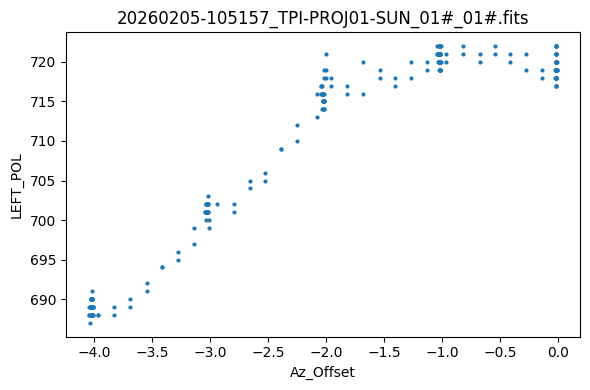

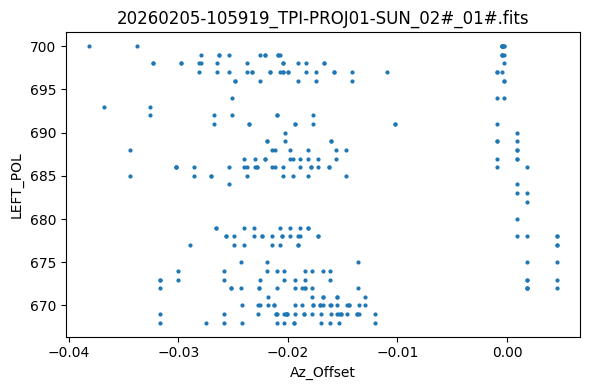

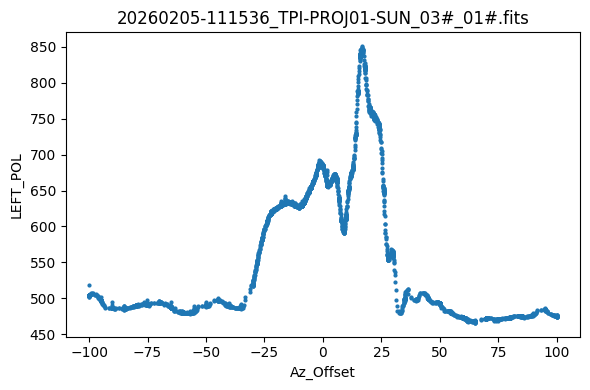

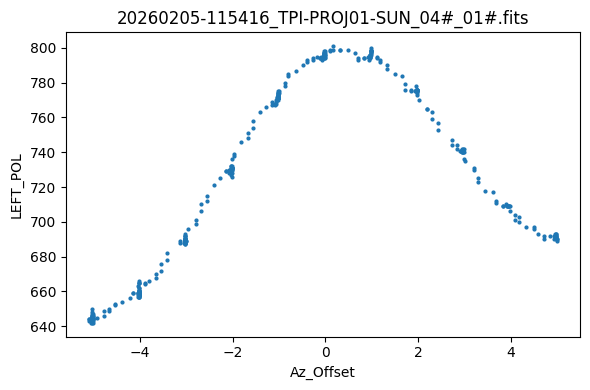

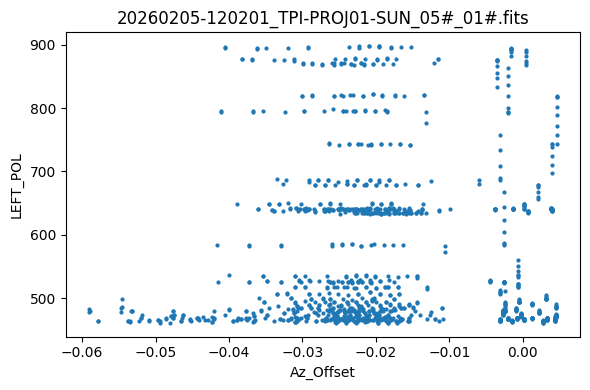

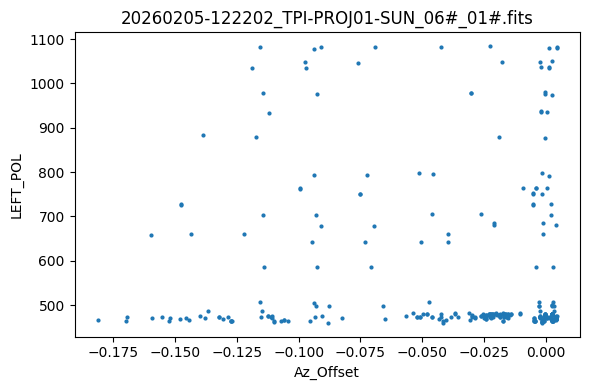

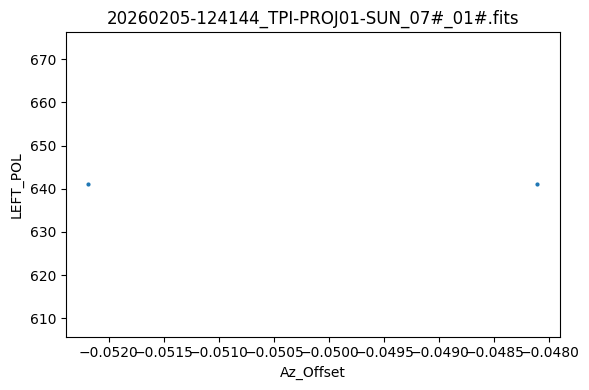

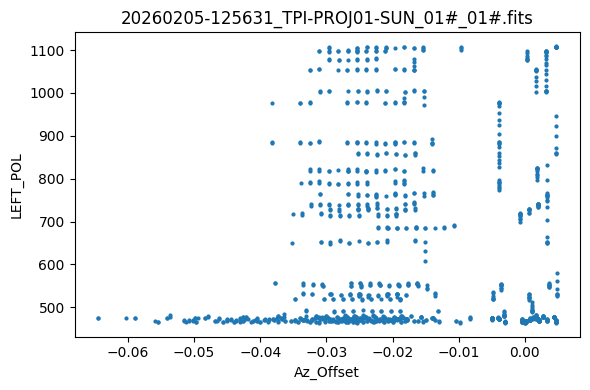

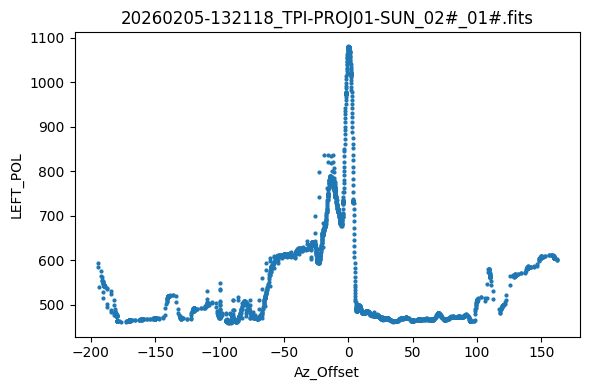

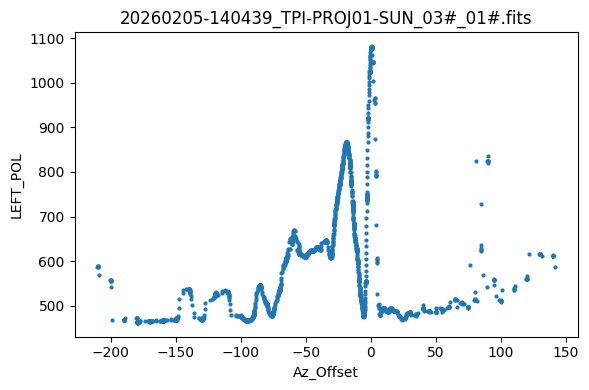

In [ ]:
for fname in fits_files[:10]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        hdr = hdul[0].header  # Access header from primary HDU (index 0)
        x = data["Az_Offset"]
        y = data["LEFT_POL"]

        #t = Time(data["JD"][0], format="jd")
        #time_str = t.iso.split(".")[0]
        #az = np.median(data["Azimuth"])
        #el = np.median(data["Elevation"])

        plt.figure(figsize=(6,4))
        plt.plot(x, y, ".", ms=4)
        plt.title(fname.split("/")[-1])
        plt.xlabel("Az_Offset")
        plt.ylabel("LEFT_POL")
        plt.tight_layout()
        plt.show()

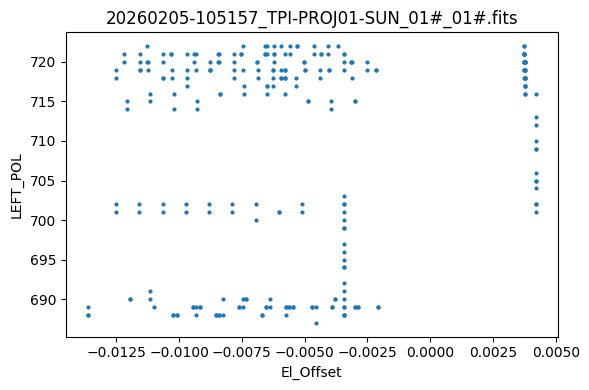

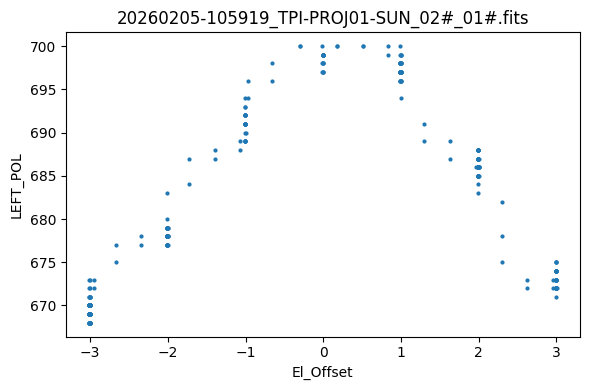

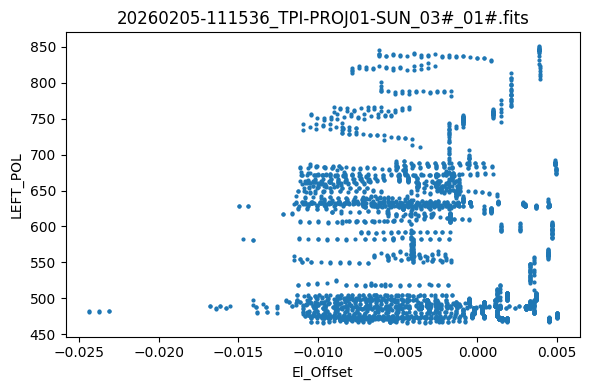

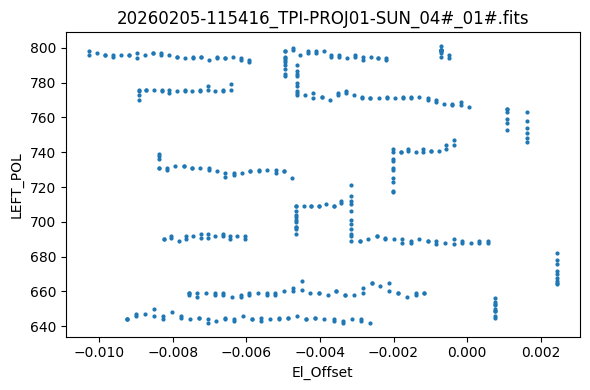

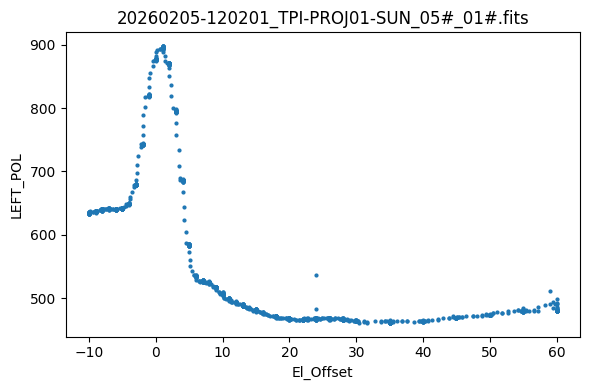

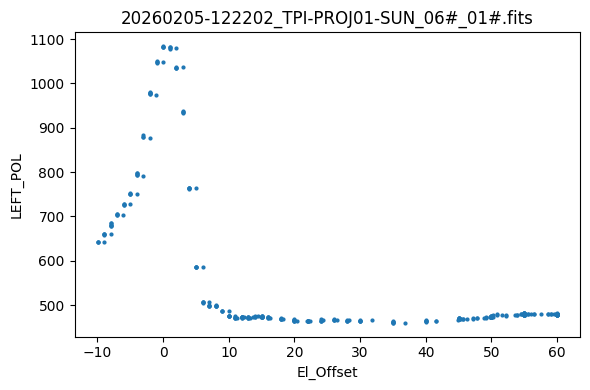

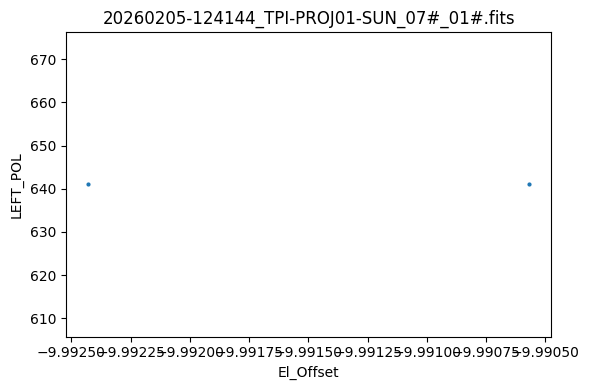

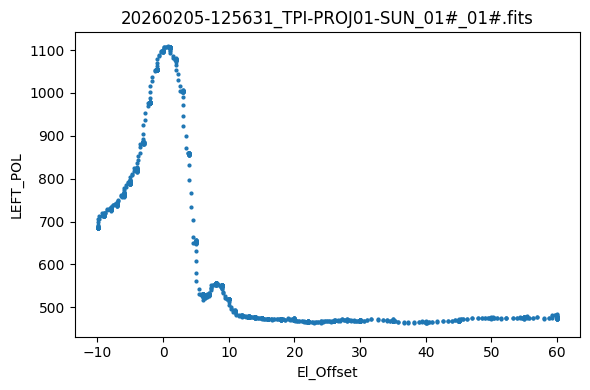

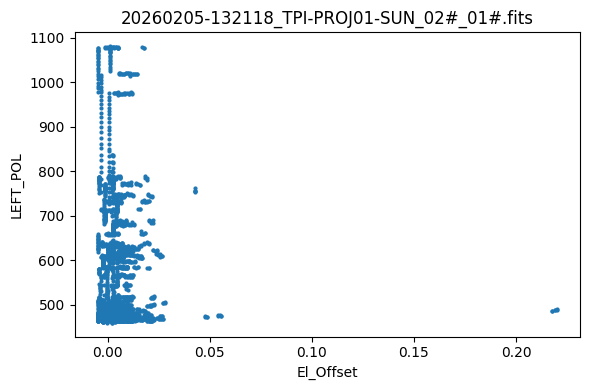

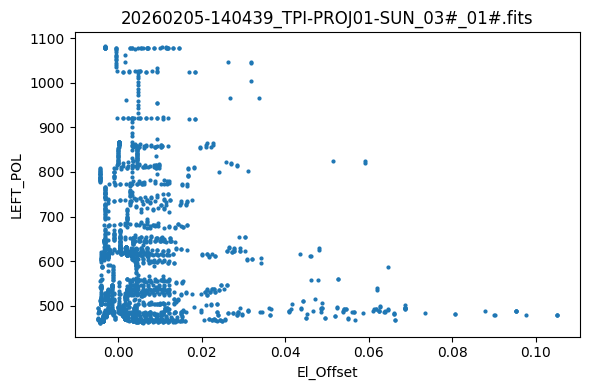

In [ ]:

for fname in fits_files[:10]:
    with fits.open(fname) as hdul:
        data = hdul[1].data
        x = data["El_Offset"]
        y = data["LEFT_POL"]

    plt.figure(figsize=(6,4))
    plt.plot(x, y, ".", ms=4)
    plt.title(fname.split("/")[-1])
    plt.xlabel("El_Offset")
    plt.ylabel("LEFT_POL")
    plt.tight_layout()
    plt.show()

In [ ]:
folder = "/content/drive/MyDrive/Colab Notebooks/RT/20260205/FITS"

file1 = folder + "/20260205-111536_TPI-PROJ01-SUN_03#_01#.fits"
file2 = folder + "/20260205-132118_TPI-PROJ01-SUN_02#_01#.fits"
file3 = folder + "/20260205-140439_TPI-PROJ01-SUN_03#_01#.fits"

def read_profile(fname, xcol="Az_Offset", ycol="LEFT_POL", hdu=1):
    with fits.open(fname) as hdul:
        d = hdul[hdu].data
        x = np.asarray(d[xcol], float)
        y = np.asarray(d[ycol], float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    idx = np.argsort(x)
    return x[idx], y[idx]

x1, y1 = read_profile(file1,xcol="Az_Offset")
x2, y2 = read_profile(file2,xcol="Az_Offset")
x3, y3 = read_profile(file3,xcol="Az_Offset")

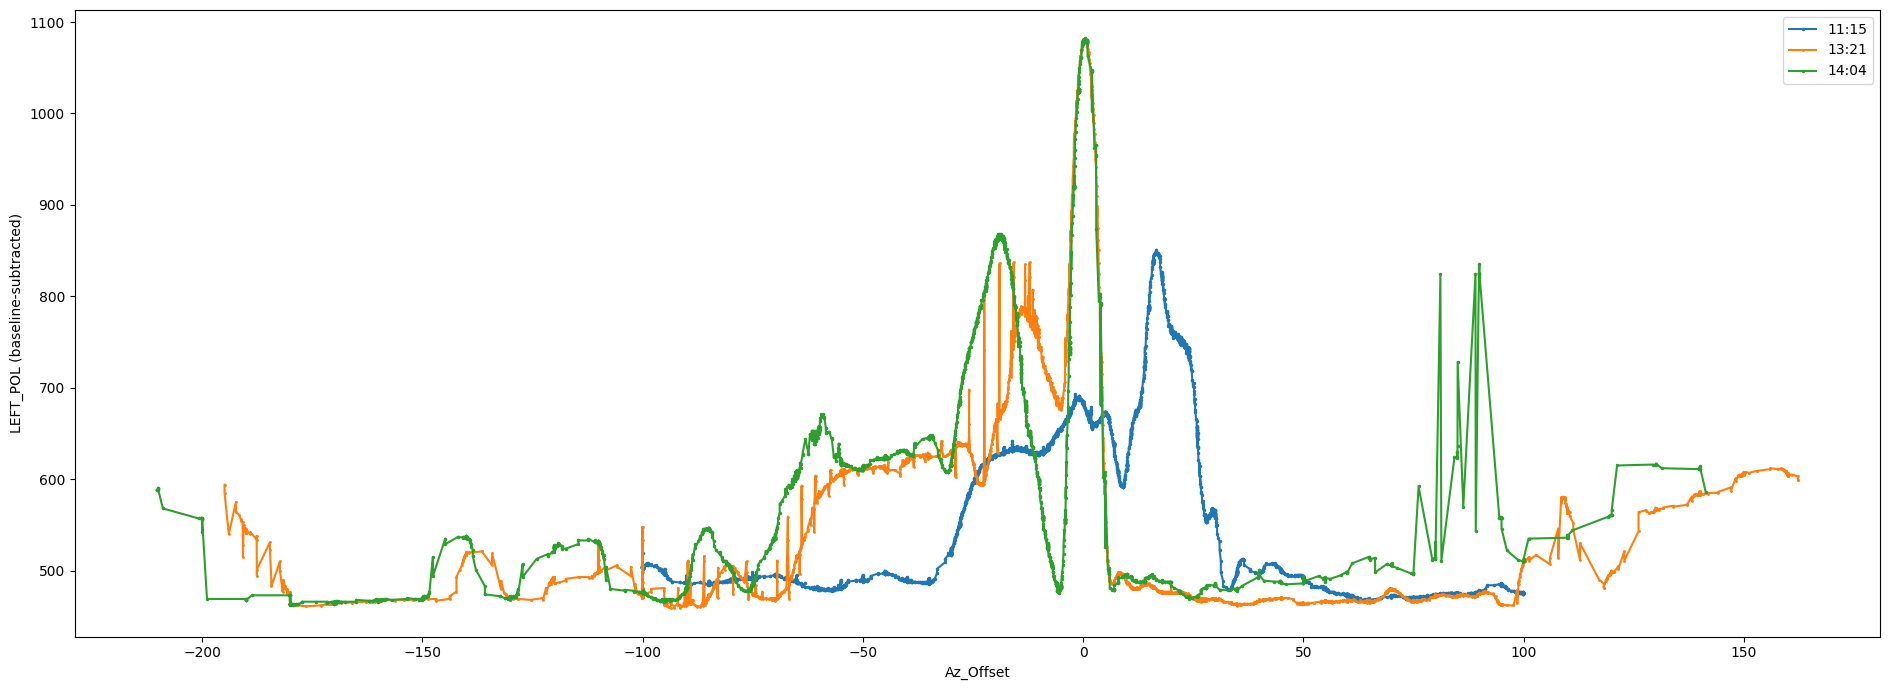

In [ ]:
plt.figure(figsize=(19,7))


plt.plot(x1, y1,'.-', label="11:15",ms=3)
plt.plot(x2, y2,'.-', label="13:21",ms=2)
plt.plot(x3, y3,'.-', label="14:04",ms=3)


plt.xlabel("Az_Offset")
plt.ylabel("LEFT_POL (baseline-subtracted)")
plt.legend()
plt.tight_layout()
plt.show()

Affected by random signals

In [ ]:
x1, y1 = read_profile1(file1,xcol="Az_Offset")
x2, y2 = read_profile1(file2,xcol="Az_Offset")
x3, y3 = read_profile1(file3,xcol="Az_Offset")

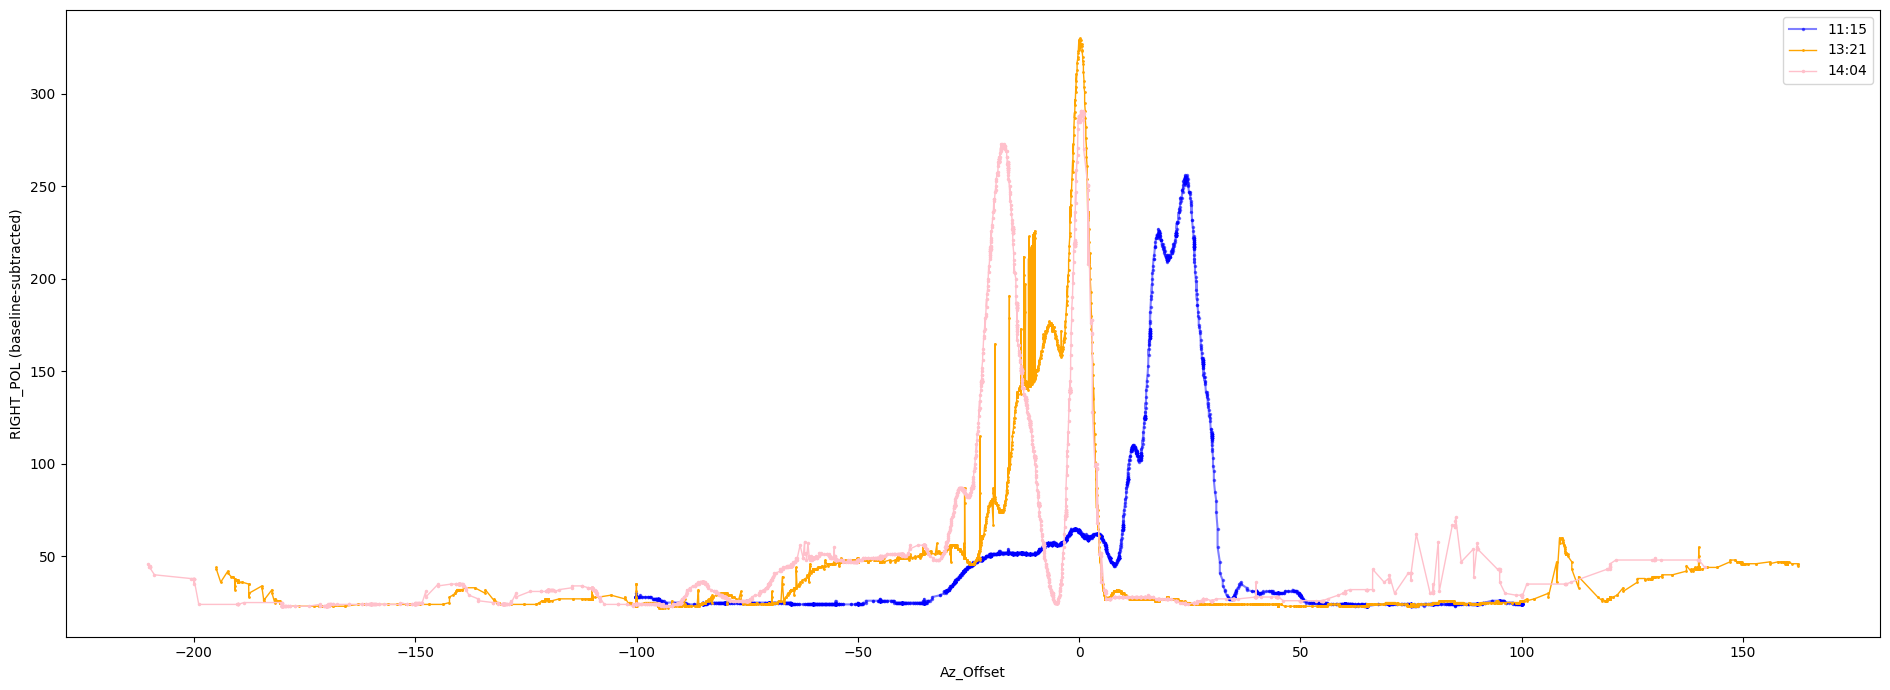

In [ ]:
plt.figure(figsize=(19,7))


plt.plot(x1, y1,'.-', label="11:15",ms=3,c='blue',alpha=0.5)
plt.plot(x2, y2,'.-', label="13:21",ms=2,c='orange',lw=1)
plt.plot(x3, y3,'.-', label="14:04",ms=3,c='pink',lw=1)


plt.xlabel("Az_Offset")
plt.ylabel("RIGHT_POL (baseline-subtracted)")
plt.legend()
plt.tight_layout()
plt.show()

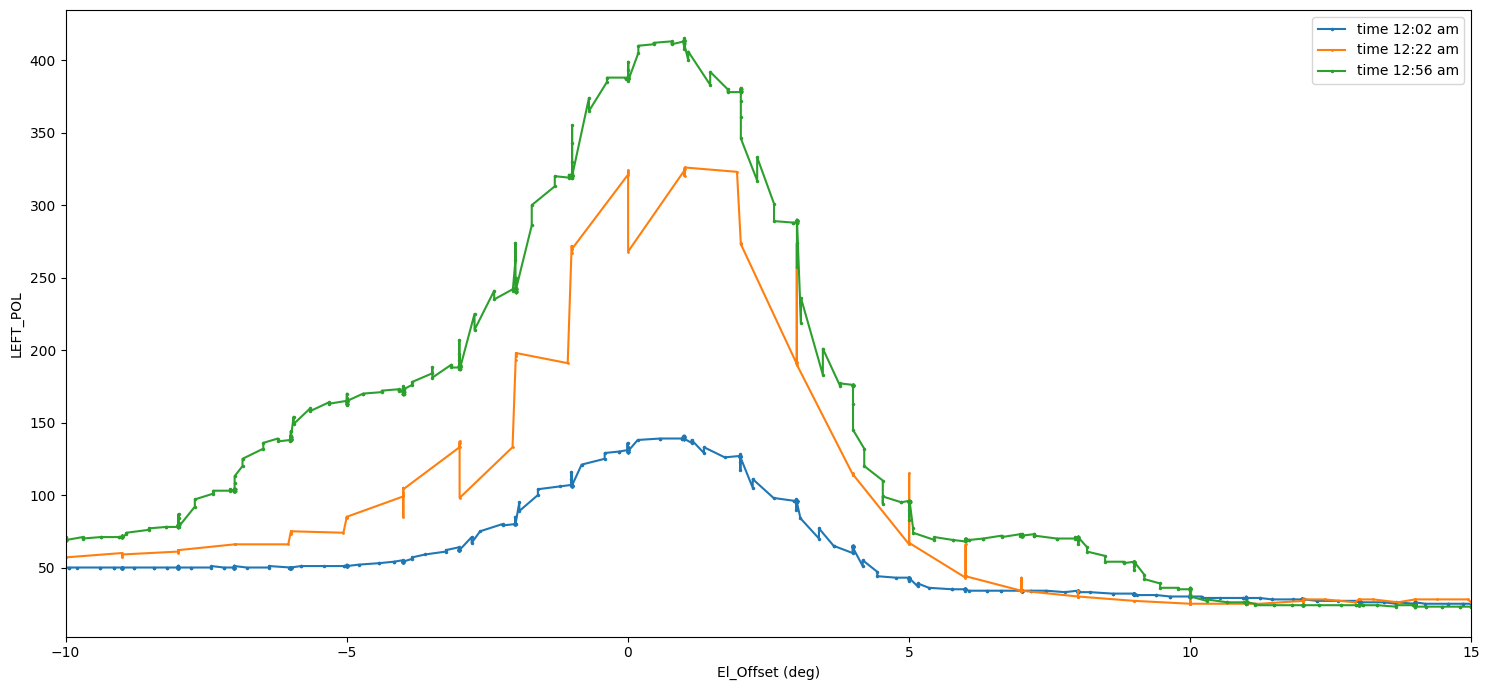

In [ ]:
file4 = folder + "/20260205-120201_TPI-PROJ01-SUN_05#_01#.fits"
file5 = folder + "/20260205-122202_TPI-PROJ01-SUN_06#_01#.fits"
file6 = folder + "/20260205-125631_TPI-PROJ01-SUN_01#_01#.fits"


x4, y4 = read_profile(file4,xcol="El_Offset")
x5, y5 = read_profile(file5,xcol="El_Offset")
x6, y6 = read_profile(file6,xcol="El_Offset")

plt.figure(figsize=(15,7))

plt.plot(x4, y4,'.-', label="time 12:02 am",ms=3)
plt.plot(x5, y5,'.-', label="time 12:22 am",ms=2)
plt.plot(x6, y6,'.-', label="time 12:56 am",ms=3)
plt.xlabel("El_Offset (deg)")
plt.ylabel("LEFT_POL")
plt.xlim(-10,15)
plt.legend()
plt.tight_layout()
plt.show()

compare the normalised LEFT_POL and the LEFT_POL_FILT

DIAMETER =                    0  / TELESCOPE diameter                            [astropy.io.fits.card]
DIAMETER =                    0  / TELESCOPE diameter                           


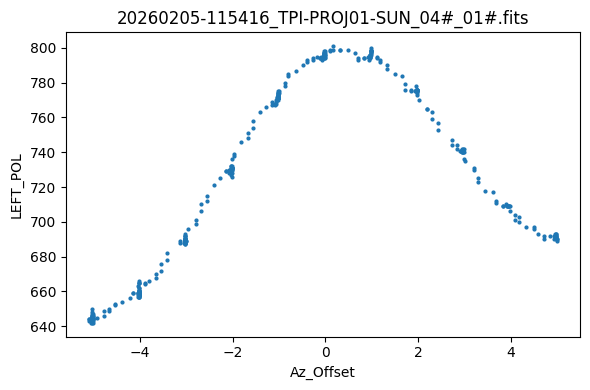

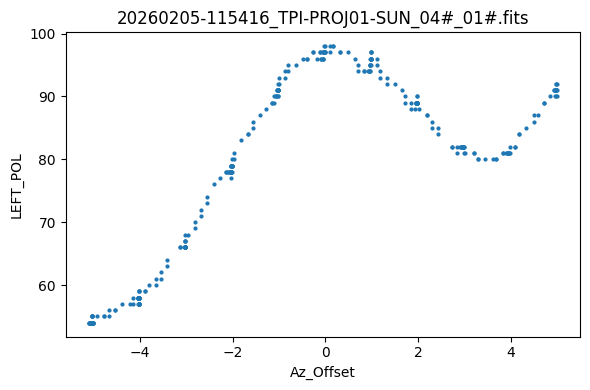

In [ ]:
fname = fits_files[3]
with fits.open(fname) as hdul:
    data = hdul[1].data
    x = data["Az_Offset"]
    y1 = data["LEFT_POL"]
    y2 = data["RIGHT_POL"]


    plt.figure(figsize=(6,4))
    plt.plot(x, y1, ".", ms=4)
    plt.title(fname.split("/")[-1])
    plt.xlabel("Az_Offset")
    plt.ylabel("LEFT_POL")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(x, y2, ".", ms=4)
    plt.title(fname.split("/")[-1])
    plt.xlabel("Az_Offset")
    plt.ylabel("LEFT_POL")
    plt.tight_layout()
    plt.show()